In [6]:
import numpy as np
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.utils.validation import check_X_y, check_array, check_is_fitted

class AdvancedFFTClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, algorithm="chasing"):
        self.algorithm = algorithm
        
    def _calculate_cue_metrics(self, x_col, y):
        best_validity = -1
        best_threshold = None
        best_direction = 1 
        
        thresholds = np.unique(x_col)
        if len(thresholds) > 10:
            thresholds = np.percentile(x_col, np.linspace(10, 90, 10))
            
        for t in thresholds:
            for direction in [1, -1]:
                preds = (x_col >= t) if direction == 1 else (x_col < t)
                
                hits = np.sum((preds == 1) & (y == 1))
                false_alarms = np.sum((preds == 1) & (y == 0))
                
                denom = hits + false_alarms
                validity = hits / denom if denom > 0 else 0
                
                if validity > best_validity:
                    best_validity = validity
                    best_threshold = t
                    best_direction = direction
                    
        return best_validity, best_threshold, best_direction

    def fit(self, X, y):
        X, y = check_X_y(X, y)
        self.classes_ = np.unique(y)
        n_samples, n_features = X.shape
        
        remaining_features = list(range(n_features))
        self.cue_order_ = []
        self.thresholds_ = {}
        self.directions_ = {}
        self.exits_ = {} 

        current_mask = np.ones(n_samples, dtype=bool)
        
        while len(remaining_features) > 0:
            best_feat = None
            best_val = -1
            best_thresh = None
            best_dir = 1
            
            for f in remaining_features:
                val, thresh, direction = self._calculate_cue_metrics(
                    X[current_mask, f], y[current_mask]
                )
                if val > best_val:
                    best_val = val
                    best_feat = f
                    best_thresh = thresh
                    best_dir = direction
            
            if best_feat is None:
                best_feat = remaining_features[0]
                best_thresh = np.median(X[current_mask, best_feat])
                best_dir = 1
                
            self.cue_order_.append(best_feat)
            self.thresholds_[best_feat] = best_thresh
            self.directions_[best_feat] = best_dir
            remaining_features.remove(best_feat)
            
            # --- CORRECTED BLOCK BEGINS HERE ---
            # Evaluate feature predictions on the FULL dataset to prevent dimension mismatch
            feat_preds = (X[:, best_feat] >= best_thresh) if best_dir == 1 else (X[:, best_feat] < best_thresh)
            
            # Intersect full predictions with the active state mask
            instances_matching_cue = current_mask & feat_preds
            # --- CORRECTED BLOCK ENDS HERE ---
            
            if np.sum(instances_matching_cue) > 0:
                exit_decision = 1 if np.mean(y[instances_matching_cue]) >= 0.5 else 0
            else:
                exit_decision = 1
                
            self.exits_[best_feat] = exit_decision
            
            current_mask = current_mask & (~instances_matching_cue)
            
            if np.sum(current_mask) == 0:
                break
                
        return self

    def predict(self, X):
        check_is_fitted(self, attributes=["cue_order_", "thresholds_", "directions_", "exits_"])
        X = check_array(X)
        n_samples = X.shape[0]
        predictions = np.zeros(n_samples, dtype=int)
        
        for i in range(n_samples):
            exited = False
            row = X[i, :]
            
            for rank, feat_idx in enumerate(self.cue_order_):
                thresh = self.thresholds_[feat_idx]
                direction = self.directions_[feat_idx]
                exit_val = self.exits_[feat_idx]
                
                condition_met = (row[feat_idx] >= thresh) if direction == 1 else (row[feat_idx] < thresh)
                
                if rank == len(self.cue_order_) - 1:
                    predictions[i] = exit_val if condition_met else (1 - exit_val)
                    exited = True
                    break
                
                if condition_met:
                    predictions[i] = exit_val
                    exited = True
                    break
            
            if not exited:
                last_feat = self.cue_order_[-1]
                predictions[i] = self.exits_[last_feat]
                
        return predictions

Above is Fast and Frugal Trees implementation.

In [8]:
 from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

# Load data
data = np.loadtxt(
    "data.csv",
    delimiter=",",
    skiprows=1
)

# Features and labels
X = data[:, :8]
y = data[:, 8]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# 2. Instantiate and train our explicit Fast-and-Frugal Model
fft_model = AdvancedFFTClassifier()
fft_model.fit(X_train, y_train)

# 3. Generate Evaluation Analytics
y_pred = fft_model.predict(X_test)
test_acc = accuracy_score(y_test, y_pred)

print(f"=== FFT Model Training Completed successfully ===")
print(f"Optimized Feature Evaluation Order: {fft_model.cue_order_}\n")
print(f"Validation Accuracy: {test_acc:.4f}\n")
print("Detailed Classification Matrix Output:")
print(classification_report(y_test, y_pred))

=== FFT Model Training Completed successfully ===
Optimized Feature Evaluation Order: [6, 7, 3, 4, 5, 1, 0, 2]

Validation Accuracy: 0.6752

Detailed Classification Matrix Output:
              precision    recall  f1-score   support

         0.0       0.68      0.50      0.58        52
         1.0       0.67      0.82      0.74        65

    accuracy                           0.68       117
   macro avg       0.68      0.66      0.66       117
weighted avg       0.68      0.68      0.67       117



Now let's try its visualization!

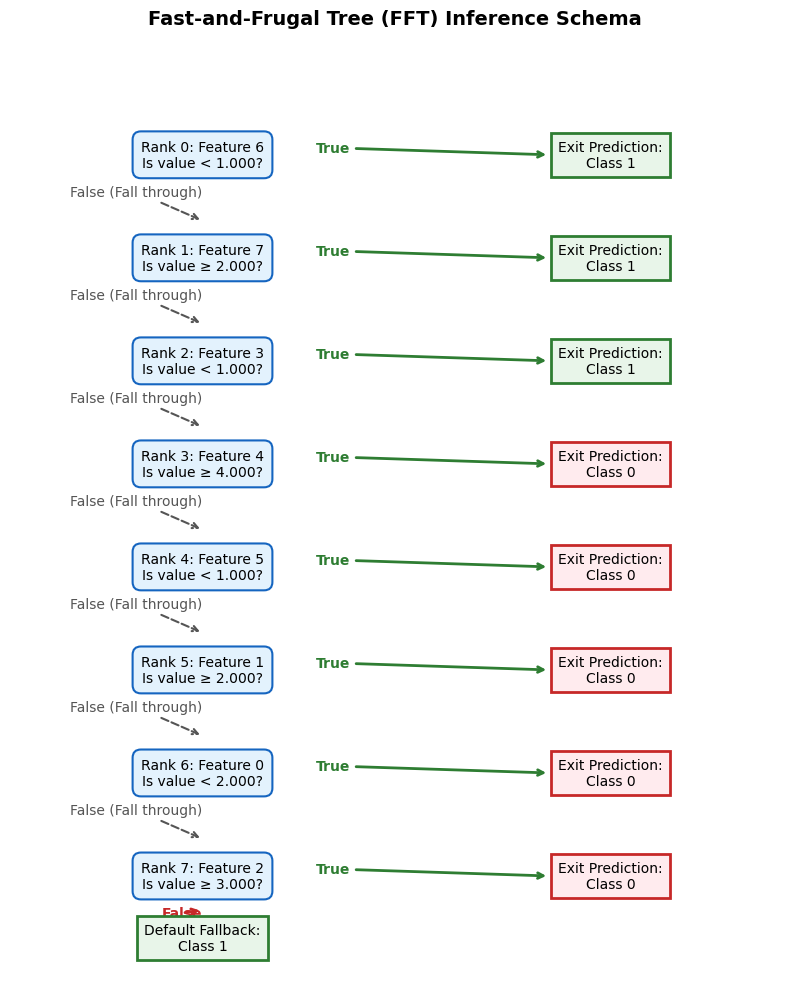

In [11]:
import matplotlib.pyplot as plt

def plot_fft_graphic(model, feature_names=None, figsize=(8, 10)):
    """
    Renders a physical flowchart layout mapping out the sequential logic paths.
    """
    if feature_names is None:
        feature_names = [f"Feature {i}" for i in range(len(model.cue_order_))]
        
    n_cues = len(model.cue_order_)
    fig, ax = plt.subplots(figsize=figsize)
    ax.axis('off')
    
    # Define vertical sequence coordinates
    y_spacing = 1.0 / (n_cues + 1)
    
    for rank, feat_idx in enumerate(model.cue_order_):
        name = feature_names[feat_idx]
        thresh = model.thresholds_[feat_idx]
        direction = model.directions_[feat_idx]
        exit_val = model.exits_[feat_idx]
        
        # Calculate current vertical depth positioning
        y_pos = 1.0 - (rank + 1) * y_spacing
        
        # 1. Generate Condition Node Box (Left side of axis)
        op_str = "≥" if direction == 1 else "<"
        node_text = f"Rank {rank}: {name}\nIs value {op_str} {thresh:.3f}?"
        ax.text(0.25, y_pos, node_text, ha='center', va='center',
                bbox=dict(boxstyle='round,pad=0.6', facecolor='#E3F2FD', edgecolor='#1565C0', lw=1.5))
        
        # 2. Draw Right Arrow indicating an immediate True exit condition
        ax.annotate('True', xy=(0.7, y_pos), xytext=(0.42, y_pos),
                    arrowprops=dict(arrowstyle="->", color="#2E7D32", lw=2),
                    va='bottom', ha='center', color="#2E7D32", weight='bold')
        
        # Draw Terminal Exit Box Target
        box_color = '#E8F5E9' if exit_val == 1 else '#FFEBEE'
        border_color = '#2E7D32' if exit_val == 1 else '#C62828'
        ax.text(0.78, y_pos, f"Exit Prediction:\nClass {exit_val}", ha='center', va='center',
                bbox=dict(boxstyle='square,pad=0.5', facecolor=box_color, edgecolor=border_color, lw=2))
        
        # 3. Draw Downward Arrow routing to the next evaluation layer
        if rank < n_cues - 1:
            next_y = 1.0 - (rank + 2) * y_spacing
            ax.annotate('False (Fall through)', xy=(0.25, next_y + 0.04), xytext=(0.25, y_pos - 0.04),
                        arrowprops=dict(arrowstyle="->", color="#555555", lw=1.5, ls='--'),
                        va='center', ha='right', color="#555555")
        else:
            # Final Layer: Render the absolute terminal fallback branch
            final_y = y_pos - y_spacing * 0.6
            ax.annotate('False', xy=(0.25, final_y + 0.03), xytext=(0.25, y_pos - 0.04),
                        arrowprops=dict(arrowstyle="->", color="#C62828", lw=2),
                        va='center', ha='right', color="#C62828", weight='bold')
            
            fallback_val = 1 - exit_val
            f_box_color = '#E8F5E9' if fallback_val == 1 else '#FFEBEE'
            f_border_color = '#2E7D32' if fallback_val == 1 else '#C62828'
            ax.text(0.25, final_y, f"Default Fallback:\nClass {fallback_val}", ha='center', va='center',
                    bbox=dict(boxstyle='square,pad=0.5', facecolor=f_box_color, edgecolor=f_border_color, lw=2))
            
    plt.title("Fast-and-Frugal Tree (FFT) Inference Schema", fontsize=14, pad=20, weight='bold')
    plt.tight_layout()
    plt.show()

plot_fft_graphic(fft_model)
